In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

c:\FAHEEM\My_Programs\RAG_Beginners\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Google api key is set


In [2]:
from typing import TypedDict, List, Annotated, Optional, Literal
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from langgraph.graph.message import BaseMessage,add_messages

class llm_schema(BaseModel):
    question: Optional[str] = Field(description="question that needs to be answered")
    path: Optional[str] = Field(description="This holds path of the document the needs to be searched")
    task: Optional[Literal["save_data", "load_data", "clear_data"]] = Field(description="What operation to perform")
    web_link: Optional[str] = Field(description="Website link used by RAG to fecth info")
    limit: Optional[int] = Field(description="Number of messages to be fetched from memory")
    search_term: str = Field(description="Main key term with which message needs to be fetched")
    timestamp: Optional[str] = Field(description="Date by which messages need to be fetched")
    topic: str = Field(description="description of the query for which user wants to request")
    file_name: str = Field(description="Just the name of the document from where data needs to be fetched")

class graph_schema(TypedDict):
    query: Annotated[List[BaseMessage], add_messages]
    question: str
    documents: List[Document]
    result: str
    task: Literal["save_data", "load_data", "clear_data"]
    web_link: str
    path: Optional[str] = Field(
        description="path must be an exact filesystem path that user entered"
    )
    tool_calls: list
    conversation: Annotated[List[BaseMessage], add_messages]
    limit: int
    search_term: str
    timestamp: str
    topic: str = Field(description="Topic of the query for which user wants to request")
    file_name: Optional[str] = Field(description="Just the name of the document from where data needs to be fetched")
    

llm_with_schema = llm.with_structured_output(llm_schema)
result = llm_with_schema.invoke("Use this weblink https://www.gsmarena.com/oneplus_nord_ce6_lite_5g-14567.php and fetch important info about one plus nord ce6 lite")
result
#Use this weblink https://www.gsmarena.com/oneplus_nord_ce6_lite_5g-14567.php and fetch important info about one plus nord ce6 lite

llm_schema(question='What are the important specifications and features of the OnePlus Nord CE6 Lite 5G?', path=None, task='load_data', web_link='https://www.gsmarena.com/oneplus_nord_ce6_lite_5g-14567.php', limit=1, search_term='OnePlus Nord CE6 Lite 5G', timestamp=None, topic='smartphone specifications', file_name='oneplus_nord_ce6_lite_5g_specs.txt')

In [3]:
from typing import Optional, Literal
from langchain_core.tools import tool
from memory import LocalMemory
from tavily import TavilyClient
from semantic_memory import ConversationMemory
from pathlib import Path
tavily_api_key = os.getenv("TAVILY_API_KEY")

tavily_client = TavilyClient(
    api_key=tavily_api_key
)

memory = LocalMemory()
semantic_memory = ConversationMemory()
@tool
def retriever_embedding_tool(question: str, file_name: Optional[str] = None, path: Optional[str] = None, web_link: Optional[str] = None):
    """
    Retrieve relevant information from a specific local document.

    Use this tool when the user asks a question about a PDF, DOCX,
    TXT, Markdown file, or other provided document.

    Args:
        question: The exact question to answer using the document.
        path: The complete filesystem path to the document.
        web_link : Link that will be used to fecth information
    """
    if web_link:
        file_to_fetch = web_link 
        
    elif file_name:
        BASE_DIR = Path.cwd()
        file_to_fetch = BASE_DIR / 'docs'
    else:
        raise ValueError(
            "Either 'path' or 'web_link' must be provided."
        )

    if not retrieve.data_exists(file_name):
        retrieve.file_loader(file_to_fetch)
        retrieve.text_splitting(file_name)

    result = retrieve.vector_embedding(question, file_name)

    return result

@tool
def memory_embedding_tool(task: Literal["save_data", "load_data", "clear_data"],
                        conversation: Optional[List] = None,
                        query: Optional[str] = None, search_term: str = None, topic: str = None):
    """
    Tool used to retrieve information from stored information using memory vector embedding from local memory+
    Example: -"Remember this conversation."
            -"Save this conversation to memory."
            -"What did I previously discuss about RAG?"
            -"Do you remember my decision about LangGraph?"               
    Args:
        query: What to search for
        task: Request to save few conversation, load from memory or clear memory
        conversation: the data that need to be stored 
    """
    if task == "save_data":

        if not conversation:
            raise ValueError(
                "conversation is required when task='save_data'"
            )

        semantic_memory.save_memory(conversation, search_term, topic)

        return "Saved Conversation Successfully"

    elif task == "load_data":

        if not query:
            raise ValueError(
                "query is required when task='load_data'"
            )

        return semantic_memory.search_memory(query)
    else:
        return semantic_memory.clear_memory()

@tool
def local_conversation_memory_tool(
    timestamp: Optional[str] = None,
    limit: Optional[int] = None,
    search_term: Optional[str] = None
):
    """
    Retrieve conversations from local conversation history.

    Use this tool when the user wants to inspect previous conversations.

    Examples:
    - "Show conversations from 8 Aug 2026"
    - "Show my last 5 conversations"
    - "Find previous conversations about LangGraph"

    Args:
        timestamp: Date/time filter.
        limit: Maximum number of conversations to return.
        search_term: Keyword or topic to filter conversations.
    """
    return memory.load_memory(
        timestamp=timestamp,
        limit=limit,
        search_term=search_term
    )

@tool
def web_search_tool(query: str, max_results: int = 5):
    """
    Search the web for current or external information.

    Use this tool when the user asks for information that may require
    current, recent, or internet-based knowledge.

    Examples:
    - "What is the latest LangGraph version?"
    - "Search for AI agent developer jobs in Dubai."
    - "What happened in the latest OpenAI announcement?"
    - "How can a person or individual earn money, search over internet"

    Args:
        query: The search query to perform.
        max_results: Maximum number of search results to return.
    """
    response = tavily_client.search(
        query=query,
        max_results=max_results
    )

    return response["results"]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4757.59it/s]


In [4]:
tools = [retriever_embedding_tool, memory_embedding_tool, web_search_tool]

llm_with_tool = llm.bind_tools(tools)


In [5]:
from RagIntegration import RagRetriever
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import ToolMessage
retrieve = RagRetriever()

def retriever_node(state: graph_schema) -> graph_schema:
    query = state['query']

    response = llm_with_tool.invoke(query)
    structured = llm_with_schema.invoke(query)
    print(response)
    
    print(f"Your structured value: {structured}")
    
    return {
        "question": structured.question,
        "path": structured.path,
        "web_link": structured.web_link,
        "task": structured.task,
        "timestamp": structured.timestamp,
        "limit": structured.limit,
        "search_term": structured.search_term,
        "topic": structured.topic,
        "file_name": structured.file_name,
        "tool_calls": response.tool_calls
    }

def tool_node(state:graph_schema) -> graph_schema:
    tool_calls = state['tool_calls']
    tool_by_name = {tool.name: tool for tool in tools}
    
    documents = []
    result = ""
    for tool_call in tool_calls:
        if tool_call["name"] == "web_search_thought":
            tool = tool_by_name["web_search_tool"]
            observation = tool.invoke({"query": state['question']})
        else:
            tool = tool_by_name[tool_call["name"]]
            observation = tool_decision(state, tool, tool_call["name"])
            
        if isinstance(observation, list):
            documents.extend(observation)

        elif isinstance(observation, str):
            result = observation
    return {
        "documents": documents,
        "result": result
    }

def tool_decision(state:graph_schema, tool:str, tool_name: str):
    if tool_name == "retriever_embedding_tool":

        return tool.invoke({
            "question": state["question"],
            "path": state["path"],
            "web_link": state['web_link'],
            "file_name": state['file_name']
        })

    elif tool_name == "memory_embedding_tool":
        return tool.invoke({
            
            "task": state["task"],
            "conversation": state["query"],
            "query": state["question"],
            "search_term": state['search_term'],
            "topic": state['topic']
        })
    
    elif tool_name == "web_search_tool":
        results =  tool.invoke({
            "query": state["question"]
        })

        return [
            Document(
                page_content=result["content"],
                metadata={
                    "title": result.get("title"),
                    "url": result.get("url")
                }
            )
            for result in results
        ]
    else:
        return tool.invoke({
            "timestamp": state['timestamp'],
            "limit": state["limit"],
            "search_term": state["search_term"]
        })

    return []

def generator_node(state: graph_schema) -> graph_schema:
    question = state['question']
    document = state['documents']
    if state["task"] == "save_data":
        return {
            "result": state['result']
        }
        
    context = '\n\n'.join(docs.page_content for docs in document)

    prompt = ChatPromptTemplate.from_messages([
        ("system", """
            You are a helpful question-answering assistant.

Answer the user's question using only the information provided in the context.

Instructions:
- Use the context as your only source of factual information.
- Combine relevant information from multiple context documents when necessary.
- You may summarize, compare, and synthesize information from the context.
- Do not use your own knowledge or invent facts that are not supported by the context.
- If the context contains only partial information, answer only the part that is supported by the context.
- If the context does not contain enough information to answer the question, say:
  "I don't know based on the provided context."
- Give a clear and direct answer.
- Do not mention the retrieval process unless the user asks about it.
            Context: {context}
        """),
        ("user", """Question: {question}""")
    ])

    chain = prompt | llm

    result = chain.invoke({"context": context, "question": question})

    return {
        "result": result.content
    }

USER_AGENT environment variable not set, consider setting it to identify your requests.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4112.69it/s]


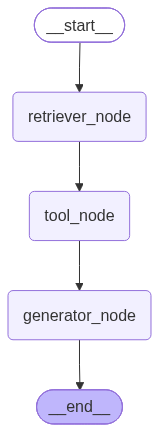

In [6]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("retriever_node", retriever_node)
graph.add_node("tool_node", tool_node)
graph.add_node("generator_node", generator_node)

graph.add_edge(START, "retriever_node")
graph.add_edge("retriever_node", "tool_node")
graph.add_edge("tool_node", "generator_node")
graph.add_edge("generator_node", END)

knowledge_assistant = graph.compile()
knowledge_assistant

In [7]:
#What is INVOLVE an AI powered on demand local service platform? examine a pdf named 29_Paper.pdf inside pdf folder of docs that is inside of C drive then Faheem then My_Programs Rag_Beginners
from langchain_core.messages import HumanMessage, AIMessage
from memory import LocalMemory
from datetime import datetime
memory = LocalMemory()

conversation = []
while True:
    query = input("Enter your request...(stop to end task)")

    if query.lower() == "stop":
        print("task ended")
        break

    conversation.append(HumanMessage(content=query))
    response = knowledge_assistant.invoke({
        "query": conversation,
        "question": "",
        "result": "",
        "path": "",
        "tool_calls": [],
        "document": [],
        "task": [],
        "limit": 0,
        "search_term": "",
        "timestamp": ""
    })
    tool_names = [
    call["name"]
    for call in response["tool_calls"]
]

    if "web_search_tool" in tool_names:
        save_data = memory.save_memory(
            response["question"],
            response["result"][0]["text"],
            datetime.now().isoformat()
        )
    elif "memory_embedding_tool" in tool_names:
        if response["task"] == 'save_data':
            save_data = memory.save_memory(
                        response["question"],
                        response["result"],
                        datetime.now().isoformat()
                    )
    elif "retriever_embedding_tool" in tool_names:
        save_data = memory.save_memory(
            response["question"],
            response["result"][0]["text"],
            datetime.now().isoformat()
        )

    if response["task"] == 'save_data':
        conversation.append(AIMessage(content=response["result"]))
        print(response["result"])
        
    elif "local_conversation_memory_tool" not in tool_names:
        conversation.append(AIMessage(content=response["result"][0]["text"]))
        print(response["result"][0]["text"])

    print(response)



content=[] additional_kwargs={'function_call': {'name': 'retriever_embedding_tool', 'arguments': '{"web_link": "https://en.wikipedia.org/wiki/Spider-Man:_Brand_New_Day", "question": "What is the budget and total collection for Spider-Man: Brand New Day?"}'}, '__gemini_function_call_thought_signatures__': {'call_3743295': 'EnEKbwERTTIPcf5EKj4BqPG7gSl4IZIgyCyCVkldZJqqWFUPqsNxhsBzdJL5yU7yoIaEY7EZMZ9xxG7L1+NHUa3YJCN3AqITYCXoUpzPM8hbW2xDotB3iDCCcefbAIhiVnZF+6HYqv35TesSpdN1hMDgUg=='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a05be2-5a0c-7a31-820b-0e54adba03b2-0' tool_calls=[{'name': 'retriever_embedding_tool', 'args': {'web_link': 'https://en.wikipedia.org/wiki/Spider-Man:_Brand_New_Day', 'question': 'What is the budget and total collection for Spider-Man: Brand New Day?'}, 'id': 'call_3743295', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 562, 'outpu

In [ ]:
from RagIntegration import RagRetriever

retrieve = RagRetriever()

# --------------------------------------------------
# 1. LOAD PDF
# --------------------------------------------------

retrieve.file_loader(
    "C:\\FAHEEM\\My_Programs\\RAG_Beginners\\docs\\pdf\\29_Paper.pdf"
)

# --------------------------------------------------
# 2. SPLIT TEXT
# --------------------------------------------------

retrieve.text_splitting()
retrieve.model_calling()

result = retrieve.vector_embedding(
    "What is the proposed solution about INVOLVE?"
)

for i, doc in enumerate(result):
    print(f"\n========== CHUNK {i + 1} ==========")
    print(doc.page_content)